# Multispectral Classification

> Tutorial multispectral classification


In [ ]:
#| default_exp tutorial_multispectral

### Setup imports

In [ ]:
import os
import pandas as pd
import torch

from monai.data import Dataset, CacheDataset
from monai.networks.nets import DenseNet169
from monai.transforms import (
    Activations,
    AsDiscrete,
    EnsureChannelFirstd,
    EnsureTyped,
    Compose,
    ConcatItemsd,
    LoadImaged,
    RandFlipd,
    RandRotate90d,
    RandZoomd,
    ScaleIntensityRangePercentilesd,
)
from monai.utils import set_determinism

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.datasets import download_file
from bioMONAI.losses import CrossEntropyLossFlat

from fastai.vision.all import accuracy, OptimWrapper

import os
import pandas as pd


---

## Download dataset

In the next cell, we will download a subset of the RXRX1 dataset from the MONAI repository. This dataset contains multispectral images that we will use for our classification task. The `download_file` function is used to download and extract the dataset to a specified directory. 

- The dataset URL is specified, and a hash is provided to ensure data integrity.
- The `extract` parameter is set to `True` to automatically extract the downloaded zip file.
- The `extract_dir` parameter is left empty, meaning the contents will be extracted to the specified directory.


>- You can change the `url` variable to point to a different dataset if needed.
>- Modify the `extract_dir` parameter to specify a different extraction directory.
>- Ensure that the `hash` value matches the dataset you are downloading to avoid data corruption issues.

In [ ]:
# Define the base URL for the dataset
url = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/rxrx1_subset_monai.zip"

download_file(url, "../_data", extract=True, hash='e80db433db641bb390ade991b81f98814a26c7de30e0da6f20e8abddf7a84538', extract_dir='')

The file has been downloaded and saved to: /home/bm/Documents/bioMONAI/nbs/_data


## Prepare dataframes and datalists

We use `pandas` to read the `metadata.csv` file and split the data into train/test sets.

In [ ]:
dftrain, dftest, _ = split_dataframe("../_data/rxrx1_subset_monai/metadata.csv", split_column='dataset')

class_map = {c: idx for idx, c in enumerate(dftrain.cell_type.unique())}
class_map_inv = dict(enumerate(dftrain.cell_type.unique()))
num_classes = len(class_map)
class_names = list(class_map.keys())

print(dftrain.columns)
dftrain

Using predefined dataset split
Index(['original_row_index', 'site_id', 'well_id', 'cell_type', 'dataset',
       'experiment', 'plate', 'well', 'site', 'well_type', 'sirna',
       'sirna_id'],
      dtype='str')


,original_row_index,site_id,well_id,cell_type,dataset,experiment,plate,well,site,well_type,sirna,sirna_id
0,45589,HEPG2-01_3_C15_2,HEPG2-01_3_C15,HEPG2,train,HEPG2-01,3,C15,2,positive_control,s15652,1114
1,59951,HEPG2-07_2_H02_2,HEPG2-07_2_H02,HEPG2,train,HEPG2-07,2,H02,2,treatment,s195435,683
2,48708,HEPG2-02_4_D13_1,HEPG2-02_4_D13,HEPG2,train,HEPG2-02,4,D13,1,treatment,s20197,85
3,46896,HEPG2-02_1_E09_1,HEPG2-02_1_E09,HEPG2,train,HEPG2-02,1,E09,1,treatment,s27069,313
4,60402,HEPG2-07_3_D09_1,HEPG2-07_3_D09,HEPG2,train,HEPG2-07,3,D09,1,treatment,s18250,405
...,...,...,...,...,...,...,...,...,...,...,...,...
995,123921,U2OS-03_2_G21_2,U2OS-03_2_G21,U2OS,train,U2OS-03,2,G21,2,treatment,s37346,1046
996,121453,U2OS-02_2_G19_2,U2OS-02_2_G19,U2OS,train,U2OS-02,2,G19,2,treatment,s38759,164
997,119034,U2OS-01_2_H20_1,U2OS-01_2_H20,U2OS,train,U2OS-01,2,H20,1,treatment,s21714,785
998,118168,U2OS-01_1_C05_1,U2OS-01_1_C05,U2OS,train,U2OS-01,1,C05,1,treatment,s19455,999


### Create datalists for training and validation
These are lists of dictionaries, with image dict-keys pointing to filepaths, plus a label dict-key.

To construct the filepaths, we follow the same folder- and filenaming pattern from the full Rxrx1 dataset.

(Note: For details, please find instructions in [./rxrx1_subset_monai/README.md#metadata](./rxrx1_subset_monai/README.md#metadata))

In [ ]:
base_path_rxrx1 = os.path.join("../_data", "rxrx1_subset_monai")
datalists = []
for df in [dftrain, dftest.reset_index()]:
    datalist = []
    for row in range(df.shape[0]):
        d = {}
        s = df.loc[row, :]
        filepaths = []
        for c in [1, 2, 3, 4, 5, 6]:
            subpath = os.path.join("images", s.experiment, f"Plate{s.plate}")
            fn = f"{s.well}_s{s.site}_w{c}.png"
            d[f"c{c}"] = os.path.join(base_path_rxrx1, subpath, fn)
        d["label"] = class_map[s.cell_type]
        datalist.append(d)
    datalists.append(datalist)
datalist_train, datalist_test = tuple(datalists)


## Data Augmentation and DataLoader Preparation

In the next cell, we will define the data augmentation techniques and prepare the data loaders for training and validation. Data augmentation is crucial for improving the generalization of our model by artificially increasing the diversity of the training dataset. We will use a combination of intensity scaling, random cropping, rotation, and flipping transformations.

- The `ScaleIntensityPercentiles` transformation scales the intensity values of the images based on the specified percentiles.
- The `RandomResizedCrop` transformation randomly crops the images to the specified size with a random scale.
- The `RandRot90` transformation randomly rotates the images by 90 degrees with the specified probability.
- The `RandFlip` transformation randomly flips the images horizontally or vertically with the specified probability.
- The `BioDataLoaders.class_from_csv` function is used to create the data loaders from the CSV file containing the image paths and labels.

> - You can adjust the `bs` variable to change the batch size.
> - Modify the parameters of the transformations to experiment with different augmentation techniques.
> - Ensure that the `fn_col` and `label_col` parameters match the columns in your CSV file.
> - Set `show_summary` to `True` to display a summary of the data loaders.

In [ ]:
transforms_train = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ScaleIntensityRangePercentilesd(
            keys=["c1", "c2", "c3", "c4", "c5", "c6"], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
        EnsureTyped(keys=["image", "label"], track_meta=False),
        RandRotate90d(keys=["c1", "c2", "c3", "c4", "c5", "c6"], prob=0.75),
        RandFlipd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], spatial_axis=[0, 1], prob=0.5),
        RandZoomd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

transforms_val = Compose(
    [
        LoadImaged(keys=["c1", "c2", "c3", "c4", "c5", "c6"], image_only=True),
        EnsureChannelFirstd(keys=["c1", "c2", "c3", "c4", "c5", "c6"]),
        ScaleIntensityRangePercentilesd(
            keys=["c1", "c2", "c3", "c4", "c5", "c6"], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=["c1", "c2", "c3", "c4", "c5", "c6"], name="image", dim=0),
    ]
)

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_classes)])


train_ds = CacheDataset(datalist_train, transform=transforms_train, num_workers=10)
test_ds = Dataset(datalist_test, transform=transforms_val)


Loading dataset: 100%|██████████| 1000/1000 [00:16<00:00, 58.91it/s]


In [ ]:
data_ops = {
    'x_keys': 'image',
    'y_keys': 'label', 
    'bs': 8,
    'val_bs': 32,
    'shuffle': True,
    'vocab': ['HEPG2', 'HUVEC', 'RPE', 'U2OS'],
    'show_summary': True,
}

data = BioDataLoaders.from_monai(train_ds, test_ds, **data_ops)


Train DataLoader
----------------
Dataset size : 1000
Batch size   : 8
Batches      : 125
Classes      : ['HEPG2', 'HUVEC', 'RPE', 'U2OS']

Batch structure:
  [0] shape=(8, 6, 512, 512) dtype=torch.float32 ~48.00 MB
  [1] shape=(8,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 48.00 MB

Valid DataLoader
----------------
Dataset size : 200
Batch size   : 32
Batches      : 7
Classes      : ['HEPG2', 'HUVEC', 'RPE', 'U2OS']

Batch structure:
  [0] shape=(32, 6, 512, 512) dtype=torch.float32 ~192.00 MB
  [1] shape=(32,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 192.00 MB


## Visualize Data Batch

In the next cell, we will visualize a batch of images from the training dataset. This step is essential for verifying that the data augmentation techniques are applied correctly and that the images are loaded as expected. The `show_batch` method of the `BioDataLoaders` class is used to display a batch of images with their corresponding labels.

- The `max_slices` parameter specifies the maximum number of slices to display for each image.
- The `layout` parameter determines the layout of the displayed images. The 'multirow' layout arranges the images in multiple rows.

> - You can adjust the `max_slices` parameter to display more or fewer slices per image.
> - Modify the `layout` parameter to experiment with different layouts, such as 'single' or 'grid'.
> - Ensure that the data loaders are correctly defined and contain the expected images and labels.

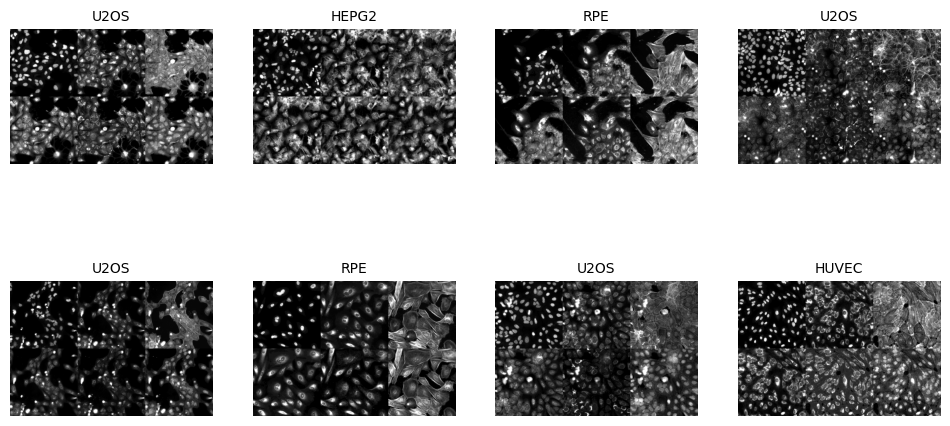

In [ ]:
data.show_batch(max_slices=6, layout='multirow')

## Visualize a Specific Image

In the next cell, we will visualize a specific image from the dataset using its index. This step is useful for inspecting individual images and verifying their quality and labels. The `do_item` method of the `BioDataLoaders` class is used to retrieve the image and its label, and the `show` method is used to display the image.


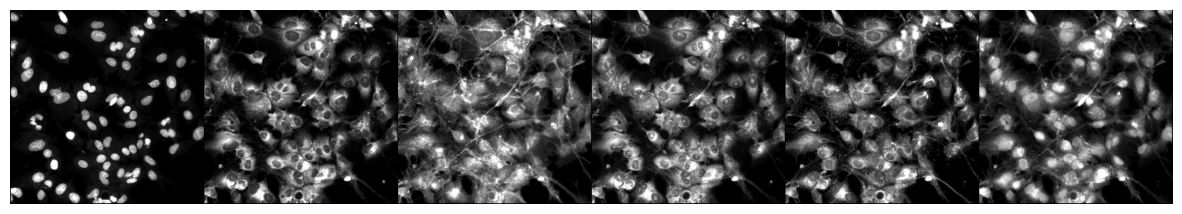

In [ ]:
from bioMONAI.visualize import mosaic_image_3d

mosaic_image_3d(data.do_item(100)[0]);

---

## Define and Train the Model

In the next cell, we will define and train a DenseNet169 model for our multispectral classification task. The model is initialized with the following parameters:
- `spatial_dims=2`: Specifies that the input images are 2D.
- `in_channels=6`: Specifies the number of input channels, which corresponds to the six multispectral channels.
- `out_channels=data.c`: Specifies the number of output channels, which corresponds to the number of classes in our dataset.
- `pretrained=True`: Initializes the model with pretrained weights.

We will also define the metrics to evaluate the model's performance during training. The `RocAuc` and `accuracy` metrics are used to measure the model's performance.

The `fastTrainer` class is used to train the model with the specified data loaders and metrics. The `fine_tune` method is called to fine-tune the model for a specified number of epochs, with an initial phase of freezing the pretrained layers.

> - You can experiment with different model architectures by replacing `DenseNet169` with other models from the `monai.networks.nets` module.
> - Adjust the `in_channels` parameter if your dataset contains a different number of channels.
> - Modify the `out_channels` parameter if your dataset has a different number of classes.
> - Experiment with different metrics by adding or removing metrics from the `metrics` list.
> - Adjust the number of epochs and the `freeze_epochs` parameter to control the training process.

In [ ]:
from monai.networks.nets import DenseNet169

model = DenseNet169(spatial_dims=2, in_channels=6, out_channels=4, pretrained=True)

In [ ]:
metrics = [accuracy]
optimizer = OptimWrapper(opt=torch.optim.Adam(model.parameters(), 1e-5))
loss_fn=CrossEntropyLossFlat()

trainer = fastTrainer(data, model, loss_fn=loss_fn, metrics=metrics, show_summary=False, lr=1e-5, show_graph=True, optimizer=optimizer)

epoch,train_loss,valid_loss,accuracy,time
0,0.761562,0.555826,0.875000,00:37
1,0.396221,0.288494,0.920000,00:37
2,0.274546,0.242822,0.910000,00:37
3,0.197724,0.125956,0.980000,00:37


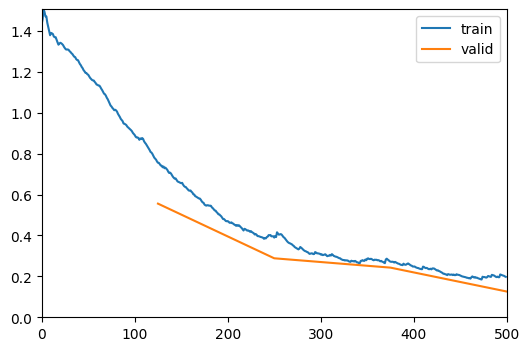

In [ ]:
trainer.fit(4)

## Save the Trained Model

In the next cell, we will save the trained model to a file. This step is crucial for preserving the model's state after training, allowing us to load and use the model later without retraining. The `save` method of the `fastTrainer` class is used to save the model to the specified file path.

- The `save` method takes the file name as an argument and saves the model's state dictionary to a file with the `.pth` extension.
- The saved model can be loaded later using the `load` method of the `fastTrainer` class.

> - You can change the file name to save the model with a different name.
> - Ensure that the directory where the model is saved exists and has write permissions.
> - Consider saving multiple versions of the model during training to keep track of different checkpoints.

In [ ]:
# trainer.save('multispectral-classification-model')

---

## Evaluate the Model on Test Data

In the next cell, we will evaluate the trained model on the test dataset. This step is crucial for assessing the model's performance on unseen data and understanding its generalization capabilities. The `BioDataLoaders.class_from_csv` function is used to create the data loader for the test dataset, and the `evaluate_classification_model` function is used to compute the evaluation metrics.

- The `fn_col` parameter specifies the columns containing the file paths for the multispectral channels.
- The `label_col` parameter specifies the column containing the labels.
- The `valid_pct` parameter is set to 0, indicating that no validation split is needed for the test dataset.
- The `item_tfms` parameter applies the `ScaleIntensityPercentiles` transformation to the test images.
- The `batch_tfms` parameter applies any batch-level transformations (if defined).
- The `bs` parameter specifies the batch size for loading the test data.
- The `evaluate_classification_model` function takes the trained model, test data loader, and evaluation metrics as inputs and returns the computed scores.

> - You can adjust the `bs` variable to change the batch size for loading the test data.
> - Modify the `fn_col` and `label_col` parameters to match the columns in your test CSV file.
> - Add or remove transformations in the `item_tfms` and `batch_tfms` lists to experiment with different preprocessing techniques.
> - Set `show_graph` to `True` to visualize the evaluation results.

In [ ]:
test_dl = test_biodataloader(data, test_ds) # type:ignore

              precision    recall  f1-score   support

       HEPG2       0.96      1.00      0.98        50
       HUVEC       0.98      1.00      0.99        50
         RPE       0.98      1.00      0.99        50
        U2OS       1.00      0.92      0.96        50

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200




Most Confused Classes:


,Actual Class,Predicted Class,Count
0,U2OS,HEPG2,2
1,U2OS,HUVEC,1
2,U2OS,RPE,1


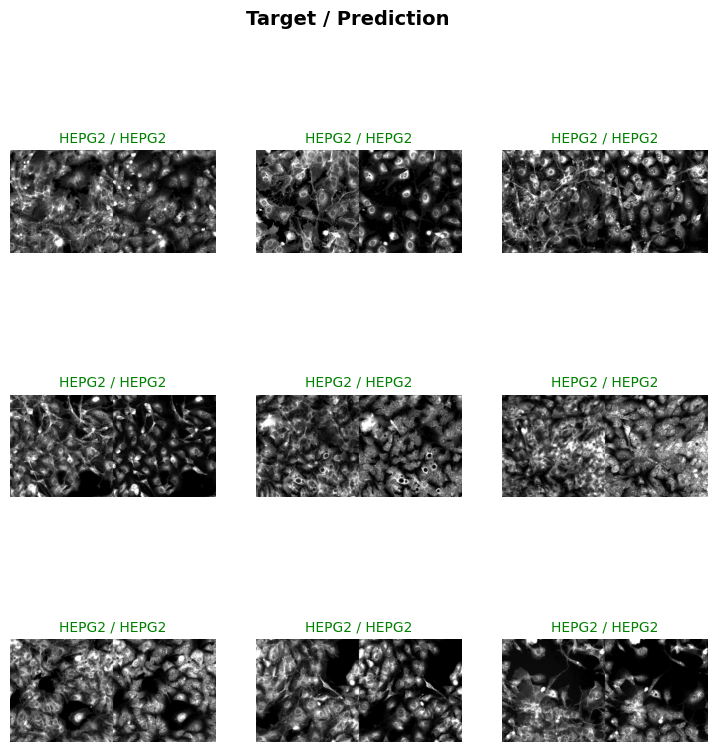

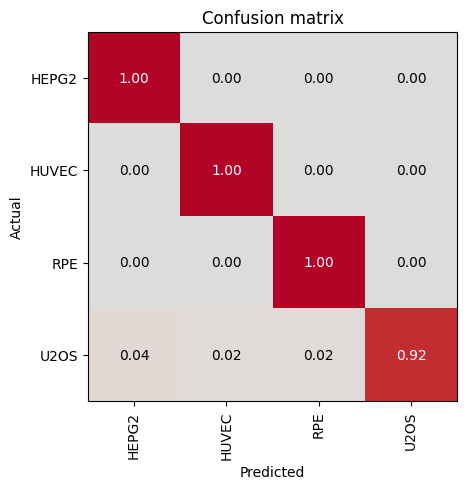

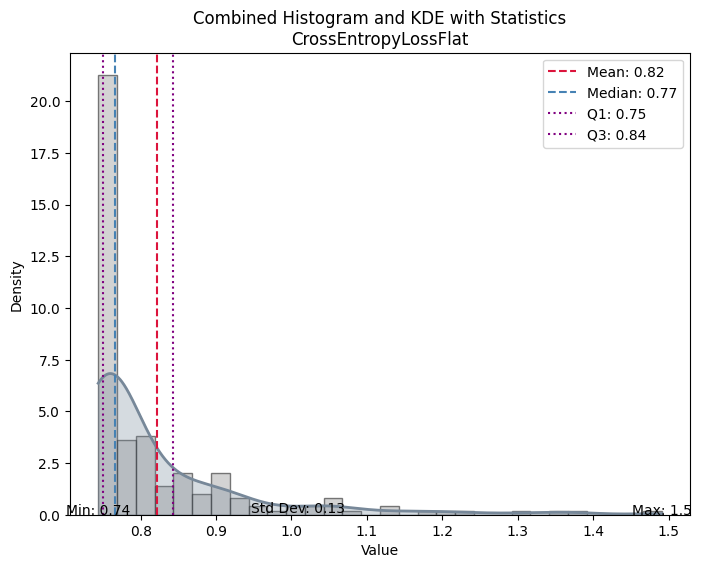

,Value
CrossEntropyLossFlat,
Mean,0.821154
Median,0.765378
Standard Deviation,0.125049
Min,0.743762
Max,1.491022
Q1,0.750168
Q3,0.842472


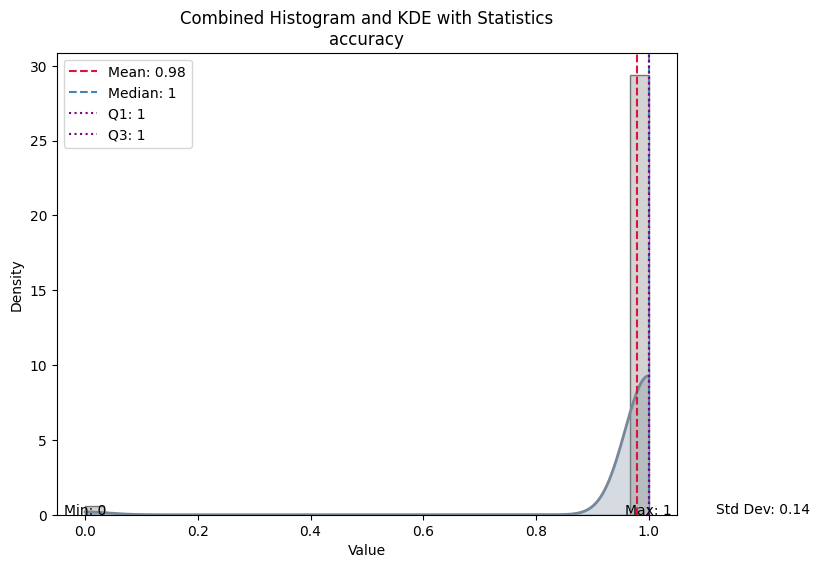

,Value
accuracy,
Mean,0.98
Median,1.00
Standard Deviation,0.14
Min,0.00
Max,1.00
Q1,1.00
Q3,1.00


In [ ]:
evaluate_classification_model(trainer, test_data=test_dl, metrics=accuracy, show_graph=True, show_results=True); # type:ignore